In [62]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = pd.read_csv('dataset/review_shopee.csv')

df.head()

,content,score,label
0,Atakkarmita syahputra,1,negatif
1,untuk admin shopee saya mohon kebijaksanaanya ...,4,positif
2,cobak kalok pembohong jangan di masukan di sop...,1,negatif
3,iklan tai,1,negatif
4,2 kali beli barang lwat apps ini lebih dari 4 ...,1,negatif


In [64]:
df.isnull().sum()

content    0
score      0
label      0
dtype: int64

In [65]:
df.dropna(inplace=True)

In [66]:
X = df['content']
y = df['label']

In [67]:
df = df[df['label'] != 'netral']

In [68]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [69]:
X = df['content']
y = df['label']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
tfidf = TfidfVectorizer(max_features=5000)

In [72]:
X_train = tfidf.fit_transform(X_train).toarray()

In [73]:
X_test = tfidf.transform(X_test).toarray()

In [74]:
model = Sequential([
    Dense(128, activation='relu',
          input_shape=(X_train.shape[1],)),

    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])

/home/codespace/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [78]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ValueError: Invalid dtype: str

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8510 - loss: 0.6773  
Loss : 0.6772733330726624
Accuracy : 0.8510000109672546


In [ ]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.71      0.73      0.72       233
           1       0.18      0.06      0.09        34
           2       0.91      0.92      0.92       733

    accuracy                           0.85      1000
   macro avg       0.60      0.57      0.58      1000
weighted avg       0.84      0.85      0.84      1000



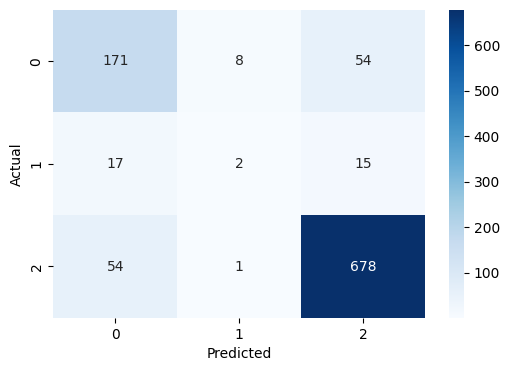

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
model.save('model/sentiment_model.h5')

In [ ]:
with open('model/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [ ]:
with open('model/label_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)